In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm.auto import tqdm
import os


c:\Users\sreeh\miniconda3\envs\your_env_name\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---- CONFIG ----
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
EPOCHS = 25
LR = 1e-4
EMBED_DIM = 256
CHECKPOINT_PATH = "best_hybrid_conv_diet.pth"

print("Using device:", DEVICE)


Using device: cuda


In [3]:
class MemoryCachedDataset(torch.utils.data.Dataset):
    def __init__(self, cache_path):
        self.data = torch.load(cache_path)
        self.samples = self.data['samples']
        self.classes = self.data['classes']
        self.class_to_idx = self.data['class_to_idx']
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        return self.samples[idx]


In [4]:
train_dataset = MemoryCachedDataset("train_cache.pt")
val_dataset   = MemoryCachedDataset("val_cache.pt")
test_dataset  = MemoryCachedDataset("test_cache.pt")

class_names = train_dataset.classes
NUM_CLASSES = len(class_names)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Classes:", class_names)


Classes: ['Cysts_Structural', 'Dysarthia', 'Laryngitis', 'Vox senilis', 'parkinson', 'spasmodische_dysphonie']


In [5]:
class ResNetTokenGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

        self.stem = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool
        )
        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3

    def forward(self, x):
        x = self.stem(x)
        f1 = self.layer1(x)   # low–mid level
        f2 = self.layer2(f1)  # mid-level
        f3 = self.layer3(f2)  # high-level
        return [f2, f3]


In [6]:
class ConvDiETHybrid(nn.Module):
    def __init__(self, num_classes, embed_dim=256):
        super().__init__()

        self.tokenizer = ResNetTokenGenerator()

        self.proj = nn.ModuleList([
            nn.Linear(128, embed_dim),  # layer2 channels
            nn.Linear(256, embed_dim),  # layer3 channels
        ])

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=8,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)

        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        features = self.tokenizer(x)
        tokens = []

        for feat, proj in zip(features, self.proj):
            # Pool frequency → preserve time
            feat = feat.mean(dim=2)        # [B, C, T]
            feat = feat.permute(0, 2, 1)   # [B, T, C]
            tokens.append(proj(feat))

        tokens = torch.cat(tokens, dim=1)  # multi-scale tokens
        encoded = self.transformer(tokens)
        pooled = encoded.mean(dim=1)

        return self.classifier(pooled)


In [7]:
model = ConvDiETHybrid(NUM_CLASSES, EMBED_DIM).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_acc = 0.0
train_losses, val_accuracies = [], []


In [8]:
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # ---- TRAIN ----
    model.train()
    running_loss = 0
    train_preds, train_labels = [], []

    for imgs, labels in tqdm(train_loader, desc="Training"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        train_preds.extend(logits.argmax(1).cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    scheduler.step()
    train_losses.append(running_loss / len(train_loader))

    # ---- VALIDATION ----
    model.eval()
    val_preds, val_labels = [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(DEVICE)
            logits = model(imgs)
            val_preds.extend(logits.argmax(1).cpu().numpy())
            val_labels.extend(labels.numpy())

    val_acc = accuracy_score(val_labels, val_preds)
    val_accuracies.append(val_acc)

    print(f"Loss: {train_losses[-1]:.4f} | Val Acc: {val_acc*100:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print("💾 Best model saved")



Epoch 1/25


Training: 100%|██████████| 433/433 [00:33<00:00, 12.92it/s]


Loss: 0.6950 | Val Acc: 77.13%
💾 Best model saved

Epoch 2/25


Training: 100%|██████████| 433/433 [00:31<00:00, 13.82it/s]


Loss: 0.3227 | Val Acc: 85.65%
💾 Best model saved

Epoch 3/25


...

Loss: 0.0013 | Val Acc: 91.03%

Epoch 24/25


Training: 100%|██████████| 433/433 [00:28<00:00, 15.14it/s]


Loss: 0.0013 | Val Acc: 91.03%

Epoch 25/25


Training: 100%|██████████| 433/433 [00:28<00:00, 15.17it/s]


Loss: 0.0010 | Val Acc: 91.48%


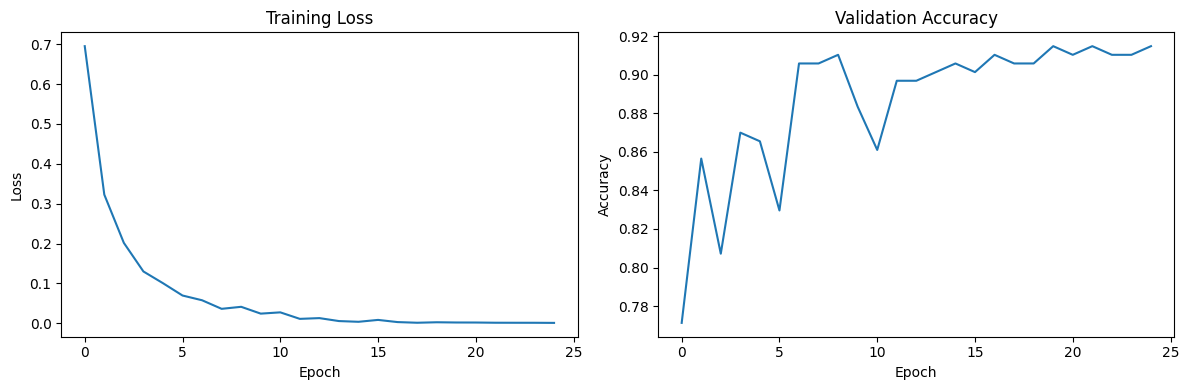

In [9]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(val_accuracies)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()


In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"Test Accuracy: {accuracy_score(all_labels, all_preds)*100:.2f}%")


Test Accuracy: 92.04%


In [14]:
print(classification_report(all_labels, all_preds, target_names=class_names))

                        precision    recall  f1-score   support

      Cysts_Structural       1.00      0.95      0.98        22
             Dysarthia       1.00      1.00      1.00        42
            Laryngitis       0.82      0.79      0.80        42
           Vox senilis       0.87      0.96      0.91        50
             parkinson       0.98      1.00      0.99        50
spasmodische_dysphonie       0.82      0.70      0.76        20

              accuracy                           0.92       226
             macro avg       0.92      0.90      0.91       226
          weighted avg       0.92      0.92      0.92       226



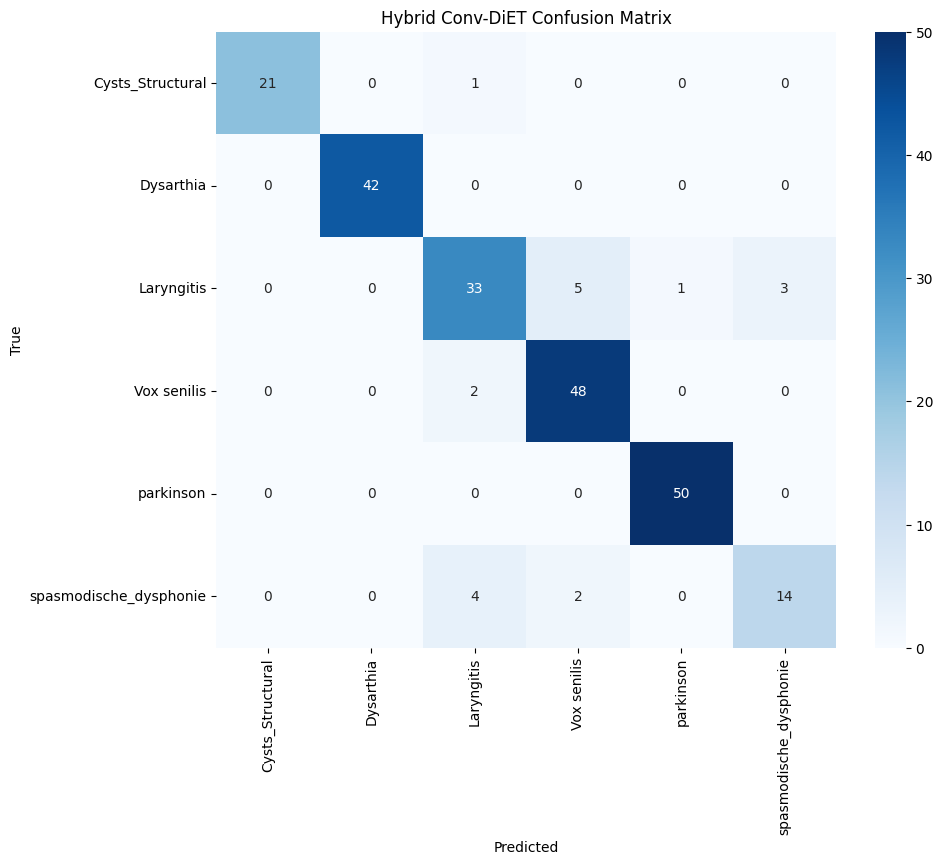

In [15]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Hybrid Conv-DiET Confusion Matrix")
plt.show()


# Update

In [16]:
class ConvDiETHybrid95(nn.Module):
    def __init__(self, num_classes, embed_dim=256):
        super().__init__()

        # --- ResNet Token Generator ---
        base = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

        self.stem = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool
        )
        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3

        # ---- FREEZE EARLY RESNET (CRITICAL) ----
        for p in self.stem.parameters():   p.requires_grad = False
        for p in self.layer1.parameters(): p.requires_grad = False
        for p in self.layer2.parameters(): p.requires_grad = False

        # ---- SCALE-AWARE PROJECTIONS ----
        self.proj2 = nn.Linear(128, embed_dim)
        self.proj3 = nn.Linear(256, embed_dim)

        # Learnable scale importance (layer3 > layer2)
        self.scale_weights = nn.Parameter(torch.tensor([0.7, 1.3]))

        # ---- DiET-Style Transformer ----
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=8,
            batch_first=True,
            dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=3)

        # ---- CNN-GUIDED TOKEN ATTENTION POOLING (KEY) ----
        self.token_score = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 1)
        )

        # ---- CLASSIFIER ----
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        # ---- CNN TOKENIZATION ----
        x = self.stem(x)
        x = self.layer1(x)
        f2 = self.layer2(x)   # [B,128,T,F]
        f3 = self.layer3(f2)  # [B,256,T,F]

        # Pool frequency → keep time
        f2 = f2.mean(dim=2).permute(0, 2, 1)  # [B,T,128]
        f3 = f3.mean(dim=2).permute(0, 2, 1)  # [B,T,256]

        t2 = self.proj2(f2) * self.scale_weights[0]
        t3 = self.proj3(f3) * self.scale_weights[1]

        tokens = torch.cat([t2, t3], dim=1)

        # ---- TRANSFORMER REASONING ----
        encoded = self.transformer(tokens)

        # ---- ATTENTION POOLING (REPLACES MEAN) ----
        scores = self.token_score(encoded)          # [B,T,1]
        weights = torch.softmax(scores, dim=1)
        pooled = (encoded * weights).sum(dim=1)

        return self.classifier(pooled)


In [19]:
# Increase recall for spasmodische_dysphonie
class_to_idx = train_dataset.class_to_idx
print(class_to_idx)

weights = torch.ones(NUM_CLASSES)
weights[class_to_idx["spasmodische_dysphonie"]] = 1.4

criterion = nn.CrossEntropyLoss(weight=weights.to(DEVICE))


{'Cysts_Structural': 0, 'Dysarthia': 1, 'Laryngitis': 2, 'Vox senilis': 3, 'parkinson': 4, 'spasmodische_dysphonie': 5}


In [20]:
model = ConvDiETHybrid95(NUM_CLASSES).to(DEVICE)

optimizer = torch.optim.AdamW([
    {"params": model.layer3.parameters(), "lr": 5e-5},
    {"params": model.proj2.parameters(),  "lr": 1e-4},
    {"params": model.proj3.parameters(),  "lr": 1e-4},
    {"params": model.transformer.parameters(), "lr": 2e-4},
    {"params": model.token_score.parameters(), "lr": 2e-4},
    {"params": model.classifier.parameters(),  "lr": 2e-4},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS
)


In [21]:
best_val = 0
train_losses, val_accs = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    scheduler.step()
    train_losses.append(running_loss / len(train_loader))

    # ---- VALIDATION ----
    model.eval()
    preds, gts = [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(DEVICE)
            logits = model(imgs)
            preds.extend(logits.argmax(1).cpu().numpy())
            gts.extend(labels.numpy())

    acc = accuracy_score(gts, preds)
    val_accs.append(acc)

    print(f"Epoch {epoch+1}: Loss={train_losses[-1]:.4f}, Val={acc*100:.2f}%")

    if acc > best_val:
        best_val = acc
        torch.save(model.state_dict(), "best_hybrid_95.pth")
        print("💾 Saved best model")


Epoch 1: Loss=0.7281, Val=77.13%
💾 Saved best model
Epoch 2: Loss=0.3008, Val=85.65%
💾 Saved best model
Epoch 3: Loss=0.1646, Val=88.34%
💾 Saved best model
Epoch 4: Loss=0.1012, Val=87.89%
Epoch 5: Loss=0.0846, Val=90.58%
💾 Saved best model
Epoch 6: Loss=0.0543, Val=89.69%
Epoch 7: Loss=0.0365, Val=90.13%
Epoch 8: Loss=0.0262, Val=91.48%
💾 Saved best model
Epoch 9: Loss=0.0351, Val=88.79%
Epoch 10: Loss=0.0228, Val=86.55%
Epoch 11: Loss=0.0428, Val=87.44%
Epoch 12: Loss=0.0106, Val=90.58%
Epoch 13: Loss=0.0099, Val=91.03%
Epoch 14: Loss=0.0091, Val=91.48%
Epoch 15: Loss=0.0105, Val=87.89%
Epoch 16: Loss=0.0070, Val=90.13%
Epoch 17: Loss=0.0054, Val=91.93%
💾 Saved best model
Epoch 18: Loss=0.0016, Val=89.24%
Epoch 19: Loss=0.0025, Val=89.69%
Epoch 20: Loss=0.0011, Val=90.13%
Epoch 21: Loss=0.0017, Val=90.13%
Epoch 22: Loss=0.0016, Val=88.79%
Epoch 23: Loss=0.0012, Val=90.58%
Epoch 24: Loss=0.0011, Val=89.69%
Epoch 25: Loss=0.0013, Val=89.24%


In [22]:
model.load_state_dict(torch.load("best_hybrid_95.pth"))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print("Test Accuracy:", accuracy_score(all_labels, all_preds)*100)
print(classification_report(all_labels, all_preds, target_names=class_names))


Test Accuracy: 89.38053097345133
                        precision    recall  f1-score   support

      Cysts_Structural       1.00      0.77      0.87        22
             Dysarthia       1.00      1.00      1.00        42
            Laryngitis       0.74      0.81      0.77        42
           Vox senilis       0.92      0.92      0.92        50
             parkinson       0.96      1.00      0.98        50
spasmodische_dysphonie       0.68      0.65      0.67        20

              accuracy                           0.89       226
             macro avg       0.88      0.86      0.87       226
          weighted avg       0.90      0.89      0.89       226

